<a href="https://colab.research.google.com/github/Kard00/Logica-programacao/blob/main/Melhorar_o_desempenho_de_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###########################
#importando as bibliotecas#
###########################
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##############################
#conectando ao bando de dados#
##############################


# Conecta ao banco de dados.
# Se não existir, é criado um banco ".db"
# Usando a instrução 'with' garante que a conexão seja fechada automaticamente.
# OBS importante: caso esqueça ou seja a conexão seja perdida, todos os comandos dará erro
# é necessário reiniciar a sessão do colab
# para isto, use o atalho: CTRL + M + . (ponto)

with sqlite3.connect('dados_vendas.db') as conexao:
    # Cria um cursor para executar comandos SQL
    cursor = conexao.cursor()

    # Cria a tabela caso não exista
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS vendas1
    (
        id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
        data_venda DATE,
        produto TEXT,
        categoria TEXT,
        valor_venda REAL
    )
    ''')

    # Inserção de dados
    cursor.execute('''
    INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
    ('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
    ('2023-01-05', 'Produto B', 'Roupas', 350.00),
    ('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
    ('2023-03-15', 'Produto D', 'Livros', 200.00),
    ('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
    ('2023-04-02', 'Produto F', 'Roupas', 400.00),
    ('2023-05-05', 'Produto G', 'Livros', 150.00),
    ('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
    ('2023-07-20', 'Produto I', 'Roupas', 600.00),
    ('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
    ('2023-09-30', 'Produto K', 'Livros', 300.00),
    ('2023-10-05', 'Produto L', 'Roupas', 450.00),
    ('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
    ('2023-12-20', 'Produto N', 'Livros', 250.00);
    ''')

    # Aplica as mudanças
    conexao.commit()


In [ ]:
import sqlite3
import pandas as pd

# Conecta ao banco de dados
conexao = sqlite3.connect('dados_vendas.db')

# Puxa os dados usando uma consulta SQL e transforma em um DataFrame (tabela do Pandas)
# O Pandas lê a tabela 'vendas1' e guarda na variável 'df' (abreviação de DataFrame)
df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

# mostrar a tabela (igual o Excel)
df_vendas

In [ ]:
###########################
### tratamento de dados ###
#######  exploração #######
###########################

In [ ]:

# mostra o tipo de dados
print(df_vendas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   data_venda   14 non-null     datetime64[ns]
 1   id_venda     14 non-null     int64         
 2   produto      14 non-null     object        
 3   categoria    14 non-null     object        
 4   valor_venda  14 non-null     float64       
 5   mes_venda    14 non-null     int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(2)
memory usage: 748.0+ bytes
None


In [ ]:
# verifica se tem e a quantidade de null
print(df_vendas.isnull().sum())

data_venda     0
id_venda       0
produto        0
categoria      0
valor_venda    0
mes_venda      0
dtype: int64


In [ ]:
# verifica o total de duplicatas
quantidade_duplicatas = df_vendas.duplicated().sum()
print(f"Linhas duplicadas encontradas: {quantidade_duplicatas}")

Linhas duplicadas encontradas: 0


In [ ]:
# remove duplicatas
tira_dup = df_vendas.drop_duplicates()

In [ ]:
# padroniza todos os textos, nesse caso, na coluna categoria
df_vendas['categoria'] = df_vendas['categoria'].str.lower().str.strip()

# dados texto para decimal
# garante que valores numéricos sejam tratados como float (decimais)
df_vendas['valor_venda'] = pd.to_numeric(df_vendas['valor_venda'], errors='coerce')

In [ ]:
# Comando usado para transformar str "10/10/1999" em data
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

In [ ]:
# Mostra as 5 primeiras linhas da tabela. Ajuda a ter uma ideia visual.
print(df_vendas.head())

  data_venda  id_venda    produto    categoria  valor_venda  mes_venda
0 2023-01-01         1  Produto A  eletrônicos       1500.0          1
1 2023-01-05         2  Produto B       roupas        350.0          1
2 2023-02-10         3  Produto C  eletrônicos       1200.0          2
3 2023-03-15         4  Produto D       livros        200.0          3
4 2023-03-20         5  Produto E  eletrônicos        800.0          3


In [ ]:
# .decribe() mostra a média, maximo, mínimo etc
print(df_vendas.describe())

                data_venda  id_venda  valor_venda  mes_venda
count                   14   14.0000    14.000000  14.000000
mean   2023-06-09 00:00:00    7.5000   628.571429   5.857143
min    2023-01-01 00:00:00    1.0000   150.000000   1.000000
25%    2023-03-16 06:00:00    4.2500   312.500000   3.000000
50%    2023-05-23 00:00:00    7.5000   525.000000   5.500000
75%    2023-09-21 00:00:00   10.7500   875.000000   8.750000
max    2023-12-20 00:00:00   14.0000  1500.000000  12.000000
std                    NaN    4.1833   407.484915   3.718088


In [ ]:
################
### Análise ####
################

In [ ]:
# PERGUNTA 1: Faturamento Total do Ano
faturamento_total = df_vendas['valor_venda'].sum()

print(f"1. FATURAMENTO TOTAL 2023: R$ {faturamento_total:,.2f}")

1. FATURAMENTO TOTAL 2023: R$ 8,800.00


In [ ]:
# PERGUNTA 2: Melhor e Pior Mês
vendas_por_mes = df_vendas.groupby('mes_venda')['valor_venda'].sum()

melhor_mes_num = vendas_por_mes.idxmax()  # Pega o número do mês
pior_mes_num = vendas_por_mes.idxmin()

print(f"\n2. MELHOR MÊS: Mês {melhor_mes_num} com R$ {vendas_por_mes.max():,.2f}")
print(f"   PIOR MÊS: Mês {pior_mes_num} com R$ {vendas_por_mes.min():,.2f}")


2. MELHOR MÊS: Mês 1 com R$ 1,850.00
   PIOR MÊS: Mês 5 com R$ 150.00


In [ ]:
# PERGUNTA 3: Melhor e Pior Produto
vendas_por_produto = df_vendas.groupby('produto')['valor_venda'].sum()

melhor_produto = vendas_por_produto.idxmax()
pior_produto = vendas_por_produto.idxmin()

print(f"\n3. PRODUTO CAMPEÃO: {melhor_produto} com R$ {vendas_por_produto.max():,.2f}")
print(f"   PRODUTO PIOR: {pior_produto} com R$ {vendas_por_produto.min():,.2f}")


3. PRODUTO CAMPEÃO: Produto A com R$ 1,500.00
   PRODUTO PIOR: Produto G com R$ 150.00


In [ ]:
# PERGUNTA 4: Sazonalidade do Produto Campeão
# Usamos a variável 'melhor_produto' que descobrimos na pergunta 3
df_melhor_produto = df_vendas[df_vendas['produto'] == melhor_produto]
vendas_melhor_produto_mes = df_melhor_produto.groupby('mes_venda')['valor_venda'].sum()

print(f"\n4. VENDAS DO '{melhor_produto}' POR MÊS:")
print(vendas_melhor_produto_mes)


4. VENDAS DO 'Produto A' POR MÊS:
mes_venda
1    1500.0
Name: valor_venda, dtype: float64


In [ ]:
# PERGUNTA 5: Sazonalidade do Pior Produto
df_pior_produto = df_vendas[df_vendas['produto'] == pior_produto]
vendas_pior_produto_mes = df_pior_produto.groupby('mes_venda')['valor_venda'].sum()

print(f"\n5. VENDAS DO '{pior_produto}' POR MÊS:")
print(vendas_pior_produto_mes)


5. VENDAS DO 'Produto G' POR MÊS:
mes_venda
5    150.0
Name: valor_venda, dtype: float64


In [ ]:
# PERGUNTA 6: CONTEXTO DE CALENDÁRIO - ISSO É ANÁLISE HUMANA
print("\n6. CONTEXTO DOS MESES EXTREMOS:")
print(f"   Melhor Mês {melhor_mes_num}: Janeiro - Pós-Natal, férias, início do ano. Gasto alto.")
print(f"   Pior Mês {pior_mes_num}: Maio - Mês sem data comercial forte, entre Dia das Mães e Namorados.")
print("   Ação: Reforçar estoque em dezembro e criar campanha 'esquenta' pra maio.")


6. CONTEXTO DOS MESES EXTREMOS:
   Melhor Mês 1: Janeiro - Pós-Natal, férias, início do ano. Gasto alto.
   Pior Mês 5: Maio - Mês sem data comercial forte, entre Dia das Mães e Namorados.
   Ação: Reforçar estoque em dezembro e criar campanha 'esquenta' pra maio.


In [ ]:
# ticket médio (faturamento total / vendas)
df_vendas.groupby('categoria')['valor_venda'].mean()

,valor_venda
categoria,
eletrônicos,1016.666667
livros,225.000000
roupas,450.000000


In [ ]:
##############
###Gráficos###
##############

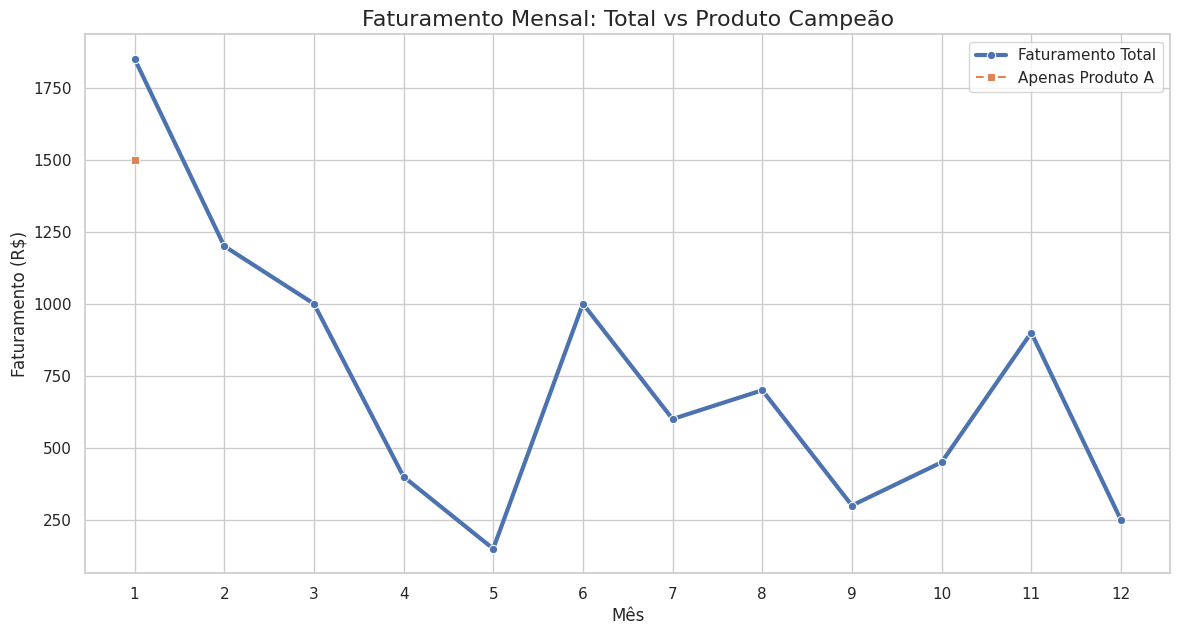

In [ ]:
# GRÁFICO 1
plt.figure(figsize=(14, 7))
# Faturamento total por mês
sns.lineplot(data=vendas_por_mes, marker='o', label='Faturamento Total', linewidth=3)

# Faturamento só do produto campeão por mês
sns.lineplot(x=vendas_melhor_produto_mes.index, y=vendas_melhor_produto_mes.values,
             marker='s', label=f'Apenas {melhor_produto}', linestyle='--')

plt.title('Faturamento Mensal: Total vs Produto Campeão', fontsize=16)
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()

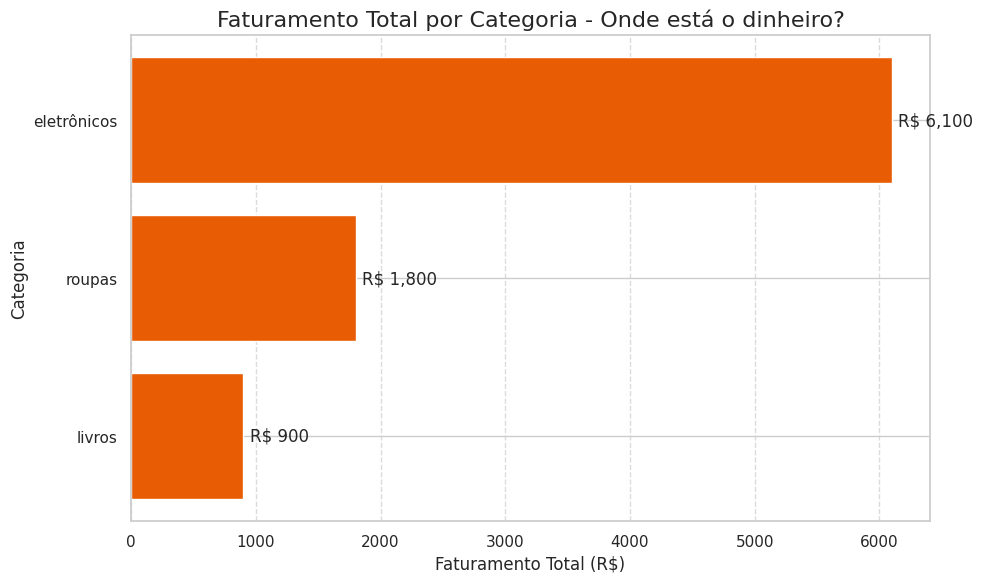

In [ ]:
# GRÁFICO 2: Faturamento por Categoria
import matplotlib.pyplot as plt

# 1. Faz a mesma agregação com Pandas
vendas_por_categoria = df_vendas.groupby('categoria')['valor_venda'].sum().sort_values()

# 2. Cria a figura
plt.figure(figsize=(10, 6))

# 3. Gráfico de barras horizontais - Matplotlib usa .barh()
bars = plt.barh(vendas_por_categoria.index, vendas_por_categoria.values, color='#e85d04')
# Usei uma cor fixa. Se quiser o degradê do 'rocket', troque por: color=plt.cm.Reds(vendas_por_categoria.values / max(vendas_por_categoria.values))

plt.title('Faturamento Total por Categoria - Onde está o dinheiro?', fontsize=16)
plt.xlabel('Faturamento Total (R$)')
plt.ylabel('Categoria')

# 4. Adiciona o valor em cada barra - mesma lógica, só muda que no barh o eixo X é o valor
for i, v in enumerate(vendas_por_categoria.values):
    plt.text(v + 50, i, f'R$ {v:,.0f}', va='center')
    # v + 50 = joga o texto 50 reais pra direita da barra
    # i = posição da barra no eixo Y
    # va='center' = alinha verticalmente no centro da barra

plt.grid(axis='x', linestyle='--', alpha=0.7) # Grade só no eixo X pra ajudar a ler
plt.tight_layout() # Ajusta pra nada ficar cortado
plt.show()

conexao.close() # Fecha a conexão no final de tudo